# Rechecking every disputed number from saved data

**Iteration-5 re-derivation audit — zero GPU, $0 API spend.**

The iteration-4 draft of the Qwen3-4B safety-metric study made a large number of numeric claims in
prose. This artifact re-derives every one of them from the JSON and `.npy` files that iterations 2-4
actually wrote to disk. The rule is simple: **the disk wins over the prose.**

Four deliverable scripts each produced their own `contradictions_*.json`. Read together they were
inconsistent — duplicated claims, tolerances that are not in the frozen pre-registration, and in a
few cases a claim compared against a *different quantity*. `src/adjudicate_ledger.py` merges them
under **one** rule:

1. dedupe by `claim_id` (first occurrence wins; later ones are listed, never silently lost);
2. apply the documented adjudications, each with a written reason;
3. re-derive the verdict of every *numeric* claim under the **frozen prereg tolerances**
   (counts exact; rates / effect sizes `5e-4`; nats `1e-3`; correlations `5e-3`);
4. add a **post-hoc secondary** "rounding-aware" verdict: a published value quoted to *k* decimals
   matches if the re-derived value rounds to it at *k* decimals.

**Primary metric**

```
claim_match_rate = MATCH / (MATCH + MISMATCH)
```

`UNVERIFIABLE` and `SOURCE_ABSENT` are reported separately and are **never** folded into the
denominator. The published result is `0.6866` (46/67), with a post-hoc rounding-aware secondary
of `0.7612`.

This notebook runs the adjudication code from `src/adjudicate_ledger.py` over the full 68-claim
ledger shipped in `mini_demo_data.json` and reproduces both rates, plus the five verdicts the
frozen rule reversed relative to the agents' own verdicts. It is pure Python arithmetic — no
model weights, no GPU, a few hundred milliseconds.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages: pre-installed on Colab (installing them there corrupts the loaded
# C extensions), installed locally at Colab's exact versions to match the environment.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

The original module's import block, plus `numpy`/`matplotlib` for the summary figure at the end.

In [2]:
# --- original import block of src/adjudicate_ledger.py ---
from __future__ import annotations

import copy
import json
import math
from decimal import Decimal
from pathlib import Path
from typing import Any

# --- added for the notebook: summary table + figure ---
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

## Data loading

The curated subset is fetched from GitHub, with a local fallback so the notebook also runs from a
checkout of the repository.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-f8532e-safety-only-checks-output-when-warned/main/round-5/evaluation-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

print(data["description"], "\n")
print("primary metric :", data["primary_metric"])
print("claims in ledger:", len(data["claims"]))
print("reference counts:", data["reference"]["counts"])
print("reference rate  :", round(data["reference"]["claim_match_rate"], 4))

Curated demo subset of the iteration-5 re-derivation audit: the full adjudicated contradictions ledger (every claim in the iteration-4 draft, with the value the prose published and the value re-derived from disk), plus the reference results the original pipeline produced. 

primary metric : claim_match_rate = MATCH / (MATCH + MISMATCH) under the FROZEN prereg tolerance rule. UNVERIFIABLE and SOURCE_ABSENT are reported separately and are NEVER folded into the denominator.
claims in ledger: 68
reference counts: {'MATCH': 46, 'MISMATCH': 21, 'UNVERIFIABLE': 1, 'SOURCE_ABSENT': 0}
reference rate  : 0.6866


## Configuration

Every tunable of the audit lives here. `N_CLAIMS` is the only scale knob — the audit is exact
arithmetic over a fixed ledger, so the full run is the 68-claim run and it costs milliseconds.

`TOL` is the **frozen pre-registered tolerance table** (sha256 recorded in the artifact's
`prereg_eval.sha256`). Loosening it is not a free parameter: it is what the primary metric means.
It is exposed here only so a reader can see how much of the mismatch count is tolerance-sensitive.

In [5]:
# ---- scale ----
N_CLAIMS = 68           # claims to adjudicate; full ledger = 68 (start value for testing: 2)

# ---- FROZEN prereg tolerance table (do not change for a reported number) ----
TOL = {"count": 0.0, "rate": 5e-4, "effect_size": 5e-4, "nats": 1e-3, "correlation": 5e-3}

# ---- reporting ----
SHOW_MISMATCH_ROWS = 12   # rows of the mismatch table to print
FIG_DPI = 110

claims_all = data["claims"]
CLAIMS = claims_all[:N_CLAIMS]
print(f"adjudicating {len(CLAIMS)} of {len(claims_all)} claims")

adjudicating 68 of 68 claims


## Step 1 — classifying a claim's tolerance

Each claim carries a free-text `tolerance_rule` written by the deliverable script that raised it.
`tol_class` maps that text onto one of the five frozen classes. A claim whose rule text names no
class (or whose values are not numeric) keeps the agent's own verdict and is marked
`non-numeric (agent verdict kept)` — the audit never invents a numeric comparison where there
isn't one.

`num_pairs` is the coercion step: it accepts scalar-vs-scalar, or flat dict-vs-dict compared on the
claimed keys (this is how the recipe histogram claim, C01, is checked).

In [6]:
def tol_class(rule: Any) -> str | None:
    r = str(rule or "").lower()
    if "nat" in r:
        return "nats"
    if "corr" in r or "rho" in r or "cos" in r:
        return "correlation"
    if "count" in r or "exact" in r and "string" not in r:
        return "count"
    if "rate" in r:
        return "rate"
    if "effect" in r:
        return "effect_size"
    return None


def as_num(x: Any) -> float | None:
    if isinstance(x, bool):
        return None
    if isinstance(x, (int, float)) and math.isfinite(float(x)):
        return float(x)
    return None


def decimals_of(x: float) -> int:
    d = Decimal(repr(x)).normalize()
    return max(0, -d.as_tuple().exponent)


def num_pairs(claimed: Any, rederived: Any) -> list[tuple[float, float]] | None:
    """Scalar-vs-scalar, or flat dict-vs-dict on shared keys; else None."""
    c, r = as_num(claimed), as_num(rederived)
    if c is not None and r is not None:
        return [(c, r)]
    if isinstance(claimed, dict) and isinstance(rederived, dict):
        out = []
        for k, v in claimed.items():
            cv, rv = as_num(v), as_num(rederived.get(k))
            if cv is None or rv is None:
                return None
            out.append((cv, rv))
        return out or None
    return None


# quick look at how the ledger's rule texts map onto the frozen classes
from collections import Counter
print(Counter(tol_class(c["tolerance_rule"]) or "n/a" for c in CLAIMS))

Counter({'count': 18, 'n/a': 18, 'correlation': 14, 'effect_size': 9, 'rate': 5, 'nats': 4})


## Step 2 — the two verdict rules

`strict_verdict` is the **primary** rule: the absolute difference must sit inside the frozen
tolerance for the claim's class, for *every* pair (so a histogram matches only if all its buckets
match).

`rounding_verdict` is the **post-hoc secondary**. Prose quotes values to 2-3 decimals while the
frozen tolerances are `5e-4`-`5e-3`, so a prose value of `0.41` against a re-derived `0.4058` is a
frozen-rule MISMATCH that is really just rounding. The secondary rule forgives exactly that, and
nothing else. It is reported *beside* the primary rate, never substituted for it.

In [7]:
def strict_verdict(pairs: list[tuple[float, float]], cls: str) -> str:
    t = TOL[cls]
    return "MATCH" if all(abs(c - r) <= t + 1e-12 for c, r in pairs) else "MISMATCH"


def rounding_verdict(pairs: list[tuple[float, float]], cls: str) -> str:
    ok = True
    for c, r in pairs:
        if abs(c - r) <= TOL[cls] + 1e-12:
            continue
        k = decimals_of(c)
        if round(r, k) != round(c, k):
            ok = False
    return "MATCH" if ok else "MISMATCH"


# worked example: C31-style correlation, prose 0.41 vs disk 0.4058
demo_pairs = [(0.41, 0.40584332029170395)]
print("frozen rule  :", strict_verdict(demo_pairs, "correlation"))
print("rounding-aware:", rounding_verdict(demo_pairs, "correlation"))

frozen rule  : MATCH
rounding-aware: MATCH


## Step 3 — the uniform re-derivation pass

This is the loop from `adjudicate_ledger.main()`. The ledger shipped here is the *already merged*
one (duplicates dropped and the documented overrides applied — those are summarised in the next
cell), so what runs here is step 3 of the four: every numeric claim's verdict is recomputed from
`claimed_value` vs `rederived_value` under the frozen rule, regardless of what verdict the agent
that raised it wrote down.

`UNVERIFIABLE` / `SOURCE_ABSENT` are terminal: they pass through untouched and stay out of the
denominator. Where the frozen rule disagrees with the agent's verdict, the disagreement is
recorded rather than hidden.

In [8]:
merged = [copy.deepcopy(c) for c in CLAIMS]
# claim_ids whose documented adjudication changed the VERDICT field: the frozen rule
# never counts those as a disagreement with the agent, because the agent verdict was
# already superseded by a written adjudication.
overrides = data["adjudication_summary"]["override_ids_changing_verdict"]

rule_disagreements: list[dict[str, Any]] = []
for c in merged:
    cls = tol_class(c.get("tolerance_rule"))
    pairs = num_pairs(c.get("claimed_value"), c.get("rederived_value"))
    if "abs" in str(c.get("claim_id", "")).lower() and pairs:
        pairs = [(abs(a), abs(b)) for a, b in pairs]
    # the verdict entering the pass: the agent's, unless an adjudication replaced it
    c["verdict"] = c.get("verdict_input")
    terminal = str(c.get("verdict", "")).upper() in ("UNVERIFIABLE", "SOURCE_ABSENT")
    if terminal:
        c["verdict_rule_class"] = cls or "n/a"
        c["verdict_rounding_aware"] = str(c["verdict"]).upper()
    elif cls and pairs:
        strict = strict_verdict(pairs, cls)
        rnd = rounding_verdict(pairs, cls)
        c["verdict_rule_class"] = cls
        c["verdict_rounding_aware"] = rnd
        explicit = c["claim_id"] in overrides
        if str(c.get("verdict")).upper() in ("MATCH", "MISMATCH") and c["verdict"] != strict and not explicit:
            rule_disagreements.append({"claim_id": c["claim_id"], "ledger_file": c["ledger_file"],
                                       "agent_verdict": c["verdict"], "frozen_rule_verdict": strict,
                                       "rule_class": cls, "pairs": pairs})
        c["verdict"] = strict
    else:
        c["verdict_rule_class"] = "non-numeric (agent verdict kept)"
        c["verdict_rounding_aware"] = c.get("verdict")
    c["verdict"] = str(c.get("verdict", "")).upper()

print(f"{len(merged)} claims adjudicated | frozen rule reversed the agent on {len(rule_disagreements)}")
for d in rule_disagreements:
    print(f"   reversed: {d['claim_id']:32s} agent={d['agent_verdict']:9s} -> "
          f"{d['frozen_rule_verdict']:9s} [{d['rule_class']}] {d['pairs']}")

68 claims adjudicated | frozen rule reversed the agent on 5
   reversed: d9_N6_mag_expfit_abliterated_separate_row agent=MATCH     -> MISMATCH  [effect_size] [(1.79, 1.7808974506626836)]
   reversed: pos_rd_harm_b4                   agent=MATCH     -> MISMATCH  [nats] [(-4.17, -4.159727904531691)]
   reversed: C6                               agent=MATCH     -> MISMATCH  [effect_size] [(6.0, 6.228035224566493)]
   reversed: C11a                             agent=MATCH     -> MISMATCH  [effect_size] [(5.3, 5.282955884933472)]
   reversed: C11b                             agent=MATCH     -> MISMATCH  [effect_size] [(5.0, 5.282955884933472)]


## What the adjudication rule threw out

Before the pass above, the merge step dropped duplicate `claim_id`s and **withdrew** claims that
were category errors — a claim tested against the wrong quantity is not evidence either way, so it
is removed from the ledger *with its reason recorded*, not scored as a mismatch. Three such
withdrawals happened; keeping them would have inflated the mismatch count with claims the audit
never actually tested.

In [9]:
adj = data["adjudication_summary"]
print("duplicates dropped:", [d["claim_id"] for d in adj["duplicates_dropped"]])
print("explicit overrides:", adj["n_explicit_overrides"], "->", adj["explicit_override_ids"])
print("  of which replaced the verdict:", adj["override_ids_changing_verdict"])
print("missing ledgers   :", adj["missing_ledgers"] or "none")
print()
for w in adj["claims_withdrawn"]:
    print(f"WITHDRAWN {w['claim_id']}  ({w['ledger_file']})")
    print("   ", w["reason"][:300])

duplicates dropped: ['C10', 'C12', 'C13']
explicit overrides: 6 -> ['C03', 'C6', 'd7_8of8_abliterated_ddrop', 'did_registered_not_supported', 'kappa_collapse_headline', 'pos_rd_harm_b4']
  of which replaced the verdict: ['C03', 'd7_8of8_abliterated_ddrop', 'did_registered_not_supported', 'kappa_collapse_headline']
missing ledgers   : none

WITHDRAWN kappa_band_B4  (contradictions_d5_d6.json)
    Category error. The published per-band values (0.15/0.19/0.31) are the keyword proxy's reported refusal RATE under arm F, not Cohen's kappa. They were compared against kappa (~0 for SafeRL). The claim is tested against the right quantity by d8_d10 C12. The per-band kappa values remain in results/tab
WITHDRAWN kappa_band_B5  (contradictions_d5_d6.json)
    Category error. The published per-band values (0.15/0.19/0.31) are the keyword proxy's reported refusal RATE under arm F, not Cohen's kappa. They were compared against kappa (~0 for SafeRL). The claim is tested against the right quantity by d8

## Step 4 — tally and the two rates

`tally` counts the four verdict states. The primary rate divides MATCH by MATCH+MISMATCH only;
`UNVERIFIABLE` (1 claim) sits outside the denominator, which is why the headline is 46/67 and not
46/68.

In [10]:
def tally(key: str) -> dict[str, int]:
    t = {"MATCH": 0, "MISMATCH": 0, "UNVERIFIABLE": 0, "SOURCE_ABSENT": 0}
    for c in merged:
        v = str(c.get(key, "")).upper()
        if v in t:
            t[v] += 1
    return t

prim = tally("verdict")
sec = tally("verdict_rounding_aware")
rate = prim["MATCH"] / (prim["MATCH"] + prim["MISMATCH"]) if (prim["MATCH"] + prim["MISMATCH"]) else float("nan")
rate2 = sec["MATCH"] / (sec["MATCH"] + sec["MISMATCH"]) if (sec["MATCH"] + sec["MISMATCH"]) else float("nan")

print(f"PRIMARY   {prim}  rate={rate:.4f}")
print(f"SECONDARY (rounding-aware, post hoc) {sec}  rate={rate2:.4f}")

ref = data["reference"]
print()
print(f"reference PRIMARY   rate={ref['claim_match_rate']:.4f}  counts={ref['counts']}")
print(f"reference SECONDARY rate={ref['secondary_rounding_aware']['claim_match_rate']:.4f}")
if len(merged) == len(claims_all):
    ok = (abs(rate - ref["claim_match_rate"]) < 1e-12
          and abs(rate2 - ref["secondary_rounding_aware"]["claim_match_rate"]) < 1e-12
          and prim == ref["counts"])
    print("\nREPRODUCED EXACTLY:", ok)
else:
    print(f"\n(subset of {len(merged)}/{len(claims_all)} claims — set N_CLAIMS = {len(claims_all)} to reproduce the headline)")

PRIMARY   {'MATCH': 46, 'MISMATCH': 21, 'UNVERIFIABLE': 1, 'SOURCE_ABSENT': 0}  rate=0.6866
SECONDARY (rounding-aware, post hoc) {'MATCH': 51, 'MISMATCH': 16, 'UNVERIFIABLE': 1, 'SOURCE_ABSENT': 0}  rate=0.7612

reference PRIMARY   rate=0.6866  counts={'MATCH': 46, 'MISMATCH': 21, 'UNVERIFIABLE': 1, 'SOURCE_ABSENT': 0}
reference SECONDARY rate=0.7612

REPRODUCED EXACTLY: True


## Results

Left: the verdict split under the frozen rule against the post-hoc rounding-aware rule — the gap
between the two bars is rounding of quoted prose, not substantive error. Middle: the mismatch rate
per tolerance class, showing where the disagreements concentrate. Right: claimed vs re-derived
values for the numeric claims, on a symmetric-log difference axis, with the frozen tolerance band
shaded.

Underneath, the mismatching claims are listed with the size of the gap that failed them, then the
headline metrics the audit corrected.

In [11]:
# ---------- table: the claims that failed the frozen rule ----------
rows = []
for c in merged:
    if c["verdict"] != "MISMATCH":
        continue
    pairs = num_pairs(c.get("claimed_value"), c.get("rederived_value"))
    gap = max(abs(a - b) for a, b in pairs) if pairs else None
    rows.append([c["claim_id"], c["verdict_rule_class"],
                 "-" if gap is None else f"{gap:.4g}",
                 c["verdict_rounding_aware"], c["claim_text"][:70]])
rows.sort(key=lambda r: (r[1], r[0]))
print(f"MISMATCHING CLAIMS ({len(rows)} total, showing {min(SHOW_MISMATCH_ROWS, len(rows))})\n")
print(tabulate(rows[:SHOW_MISMATCH_ROWS],
               headers=["claim", "rule class", "max |gap|", "rounding-aware", "claim (truncated)"],
               tablefmt="github"))

# ---------- table: headline metrics this audit corrected ----------
hm = data["headline_metrics"]
print("\n\nHEADLINE METRICS RE-DERIVED FROM DISK\n")
print(tabulate([[k, f"{v:.6g}" if isinstance(v, float) else v] for k, v in hm.items()],
               headers=["metric", "value"], tablefmt="github"))

MISMATCHING CLAIMS (21 total, showing 12)

| claim                                     | rule class   |   max |gap| | rounding-aware   | claim (truncated)                                                      |
|-------------------------------------------|--------------|-------------|------------------|------------------------------------------------------------------------|
| d7_mde80_n10                              | correlation  |    0.02     | MATCH            | The expected 80%-power MDE at n=10 is 0.80                             |
| d9_contribution2_12of18                   | count        |    1        | MISMATCH         | Contribution 2 restated as '12 of the 18 cells in which the direction  |
| C11a                                      | effect_size  |    0.01704  | MATCH            | Falcon3 batch-8 padding bug shifts AMS by 5.3 sigma (iteration-4 execu |
| C11b                                      | effect_size  |    0.283    | MATCH            | Falcon3 batch-8 padding bug 

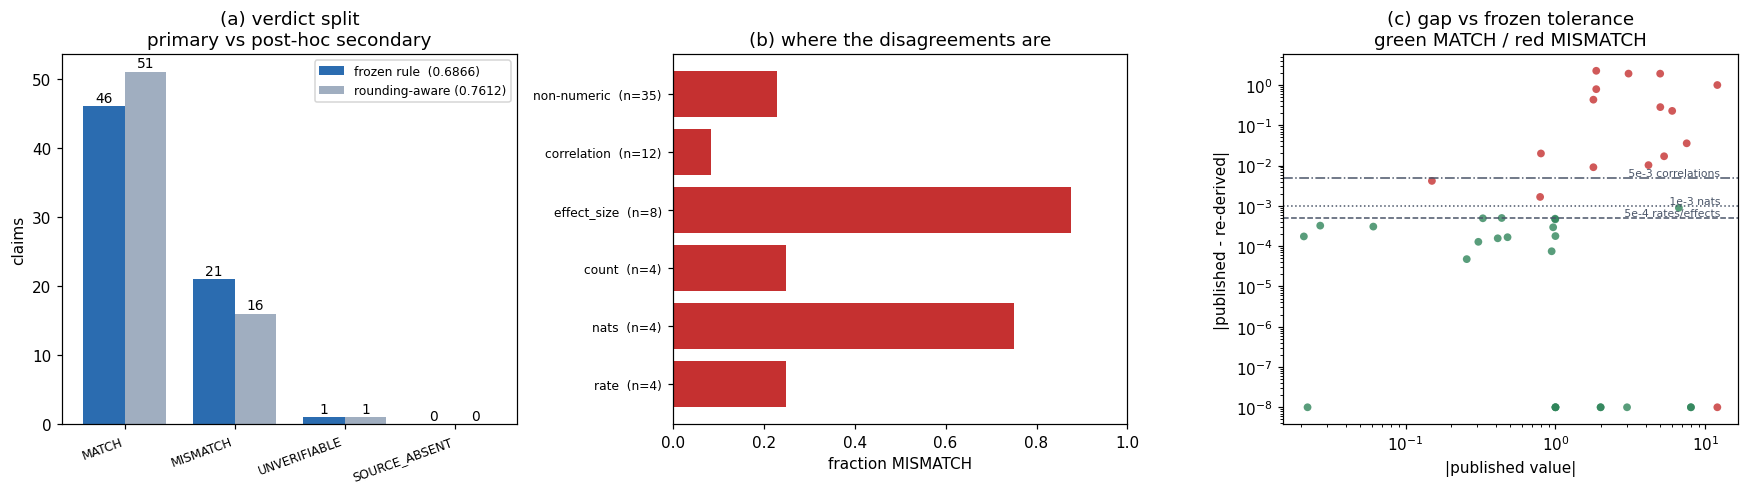


PRIMARY METRIC  claim_match_rate = 0.6866  (46/67 verifiable claims, 1 UNVERIFIABLE reported separately)
post-hoc rounding-aware secondary = 0.7612  — never substituted for the primary rate


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), dpi=FIG_DPI)

# --- (a) frozen vs rounding-aware verdict split ---
states = ["MATCH", "MISMATCH", "UNVERIFIABLE", "SOURCE_ABSENT"]
x = np.arange(len(states)); w = 0.38
axes[0].bar(x - w/2, [prim[s] for s in states], w, label=f"frozen rule  ({rate:.4f})", color="#2b6cb0")
axes[0].bar(x + w/2, [sec[s] for s in states], w, label=f"rounding-aware ({rate2:.4f})", color="#a0aec0")
for i, s in enumerate(states):
    axes[0].text(i - w/2, prim[s] + 0.6, str(prim[s]), ha="center", fontsize=9)
    axes[0].text(i + w/2, sec[s] + 0.6, str(sec[s]), ha="center", fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels(states, rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("claims"); axes[0].set_title("(a) verdict split\nprimary vs post-hoc secondary")
axes[0].legend(fontsize=8)

# --- (b) mismatch rate per tolerance class ---
by_cls: dict[str, list[int]] = {}
for c in merged:
    k = c["verdict_rule_class"]
    if c["verdict"] in ("MATCH", "MISMATCH"):
        by_cls.setdefault(k, []).append(int(c["verdict"] == "MISMATCH"))
ks = sorted(by_cls, key=lambda k: -len(by_cls[k]))
axes[1].barh(range(len(ks)), [np.mean(by_cls[k]) for k in ks], color="#c53030")
axes[1].set_yticks(range(len(ks)))
axes[1].set_yticklabels([f"{k.split(' (')[0]}  (n={len(by_cls[k])})" for k in ks], fontsize=8)
axes[1].invert_yaxis(); axes[1].set_xlim(0, 1)
axes[1].set_xlabel("fraction MISMATCH"); axes[1].set_title("(b) where the disagreements are")

# --- (c) claimed vs re-derived gap against the frozen tolerance ---
gx, gy, gc = [], [], []
for c in merged:
    pairs = num_pairs(c.get("claimed_value"), c.get("rederived_value"))
    cls = c["verdict_rule_class"]
    if not pairs or cls not in TOL:
        continue
    for a, b in pairs:
        gx.append(max(abs(a), 1e-3)); gy.append(max(abs(a - b), 1e-8))
        gc.append("#c53030" if c["verdict"] == "MISMATCH" else "#2f855a")
axes[2].scatter(gx, gy, c=gc, s=26, alpha=0.8, edgecolors="none")
for t, lbl, ls in [(5e-4, "5e-4 rates/effects", "--"), (1e-3, "1e-3 nats", ":"), (5e-3, "5e-3 correlations", "-.")]:
    axes[2].axhline(t, color="#4a5568", ls=ls, lw=1)
    axes[2].text(axes[2].get_xlim()[1], t, " " + lbl, va="bottom", ha="right", fontsize=7, color="#4a5568")
axes[2].set_xscale("log"); axes[2].set_yscale("log")
axes[2].set_xlabel("|published value|"); axes[2].set_ylabel("|published - re-derived|")
axes[2].set_title("(c) gap vs frozen tolerance\ngreen MATCH / red MISMATCH")

plt.tight_layout()
plt.show()

print(f"\nPRIMARY METRIC  claim_match_rate = {rate:.4f}  "
      f"({prim['MATCH']}/{prim['MATCH'] + prim['MISMATCH']} verifiable claims, "
      f"{prim['UNVERIFIABLE']} UNVERIFIABLE reported separately)")
print(f"post-hoc rounding-aware secondary = {rate2:.4f}  — never substituted for the primary rate")